# 📝 Instrucciones

## Prediciendo la diabetes

En el proyecto anterior vimos cómo podíamos utilizar un árbol de decisión para predecir conjuntos de datos relacionados con la clasificación y la regresión. Sin embargo, ¿sabías que podemos mejorar la predicción de un árbol utilizando un random forest?

Como hemos estudiado, un random forest es una agrupación de árboles generados con porciones aleatorias de los datos y con criterios también aleatorios. Esta visión nos permitiría mejorar la efectividad del modelo cuando un árbol individual no es suficiente.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el accuracy.

# Paso 1: Carga del conjunto de datos

**Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).**

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. 

| Variable                 | Descripción                                                                    | Tipo             |
| ------------------------ | ------------------------------------------------------------------------------ | ---------------- |
| Pregnancies              | Número de embarazos del paciente                                               | Numérico         |
| Glucose                  | Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral | Numérico         |
| BloodPressure            | Presión arterial diastólica (mm Hg)                                            | Numérico         |
| SkinThickness            | Grosor del pliegue cutáneo del tríceps (mm)                                    | Numérico         |
| Insulin                  | Insulina sérica de 2 horas (mu U/ml)                                           | Numérico         |
| BMI                      | Índice de masa corporal                                                        | Numérico         |
| DiabetesPedigreeFunction | Función de pedigrí de diabetes                                                 | Numérico         |
| Age                      | Edad del paciente                                                              | Numérico         |
| Outcome                  | Resultado: 0 = no diabetes, 1 = diabetes                                       | Numérico (clase) |

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [60]:
X_train = pd.read_csv("../data/processed/diabetes/X_train.csv")
y_train = pd.read_csv("../data/processed/diabetes/y_train.csv")
X_test = pd.read_csv("../data/processed/diabetes/X_test.csv")
y_test = pd.read_csv("../data/processed/diabetes/y_test.csv")

## Paso 2: Construye un random forest

Una forma de optimizar y mejorar los resultados cuando usamos árboles de decisión es generar un random forest con árboles suficientes de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los dos hiperparámetros que definen al árbol con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

In [61]:
#Entrenamos el modelo del rándom forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train.values.ravel())


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

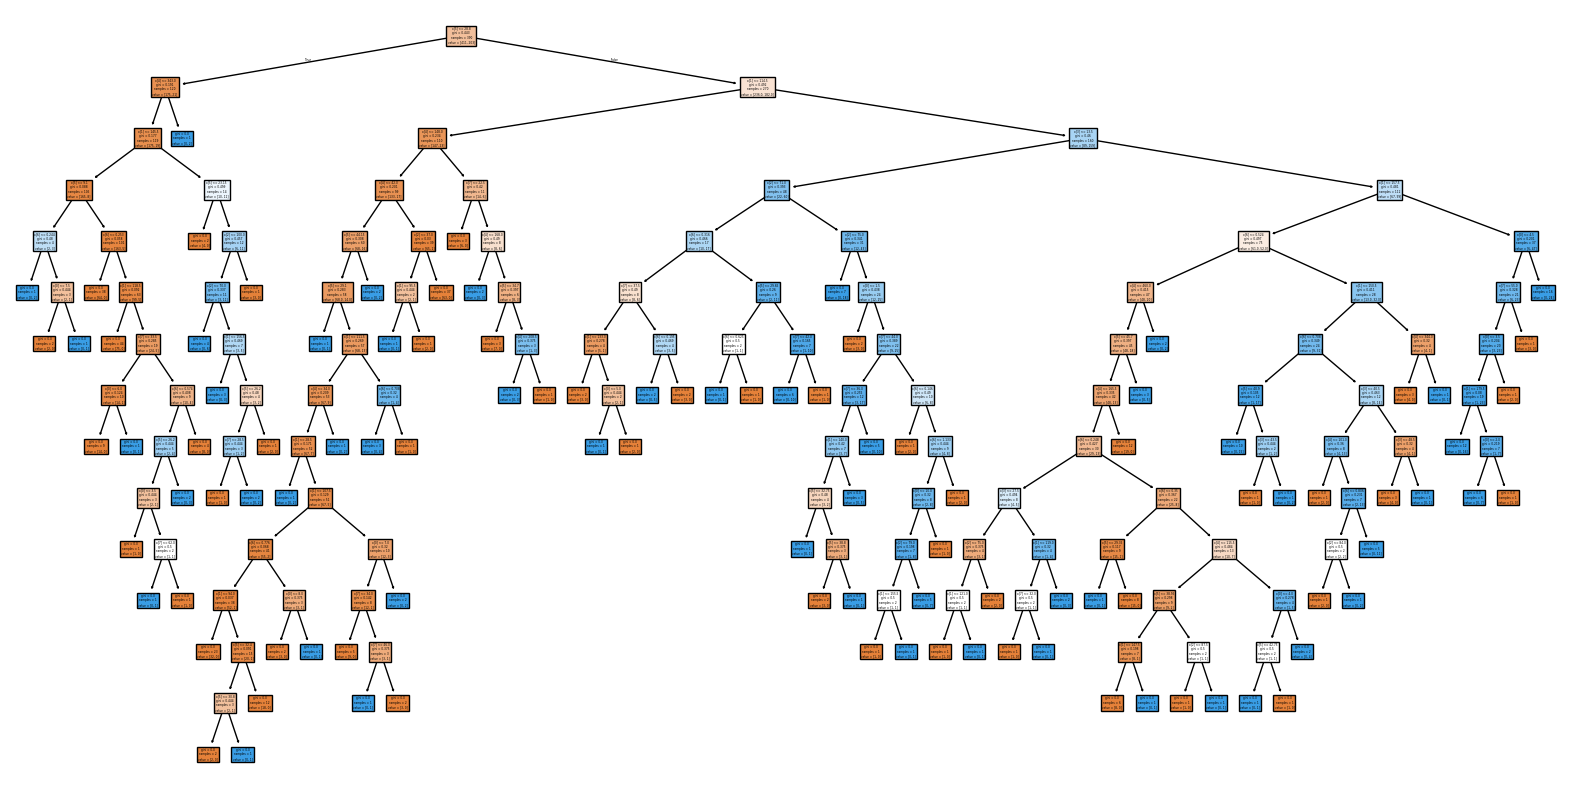

In [62]:
#Visualizamos el modelo
fig, axis = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
tree.plot_tree(model.estimators_[0], filled=True, ax=axis)
plt.show()

In [63]:
#Predcción del modelo
y_pred = model.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [64]:
accuracy_score(y_test, y_pred)

0.7597402597402597

In [65]:
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



| Métrica | Clase | Árbol (Gini) | Árbol Optimizado | Random Forest |
|--------|-------|-------------|------------------|---------------|
| Precision | 0 | 0.76 | 0.72 | 0.79 |
| Precision | 1 | 0.64 | 0.56 | 0.68 |
| Recall | 0 | 0.85 | 0.83 | 0.85 |
| Recall | 1 | 0.50 | 0.41 | 0.59 |
| F1-score | 0 | 0.80 | 0.77 | 0.82 |
| F1-score | 1 | 0.56 | 0.47 | 0.63 |
| Accuracy | - | 0.73 | 0.68 | 0.76 |
| Macro avg (F1) | - | 0.68 | 0.62 | 0.73 |
| Weighted avg (F1) | - | 0.72 | 0.67 | 0.76 |

**Interpretación:

1. El Random Forest es el mejor modelo en todos los aspectos
2. Con precisión del 68%, Random Forest diagnostica 32 falsos positivos de diabetes de cada 100
3. El recall, aunque sigue siendo bajo, mejoró considerablemente. con 59% para la clase 1, significa que predice 41 falsos negativos por cada 100 pacientes que realmente tienen diabetes.
4. De cada 100 pacientes, 76% (accuracy) fueron bien diagnosticados.

In [66]:
#Intentamos optimizar modificando hiperparámetros. Los valores por defecto según la documentación de sklearn son: n_estimators=100, max_depth=None, random_state=None
model_opt = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model_opt.fit(X_train, y_train.values.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

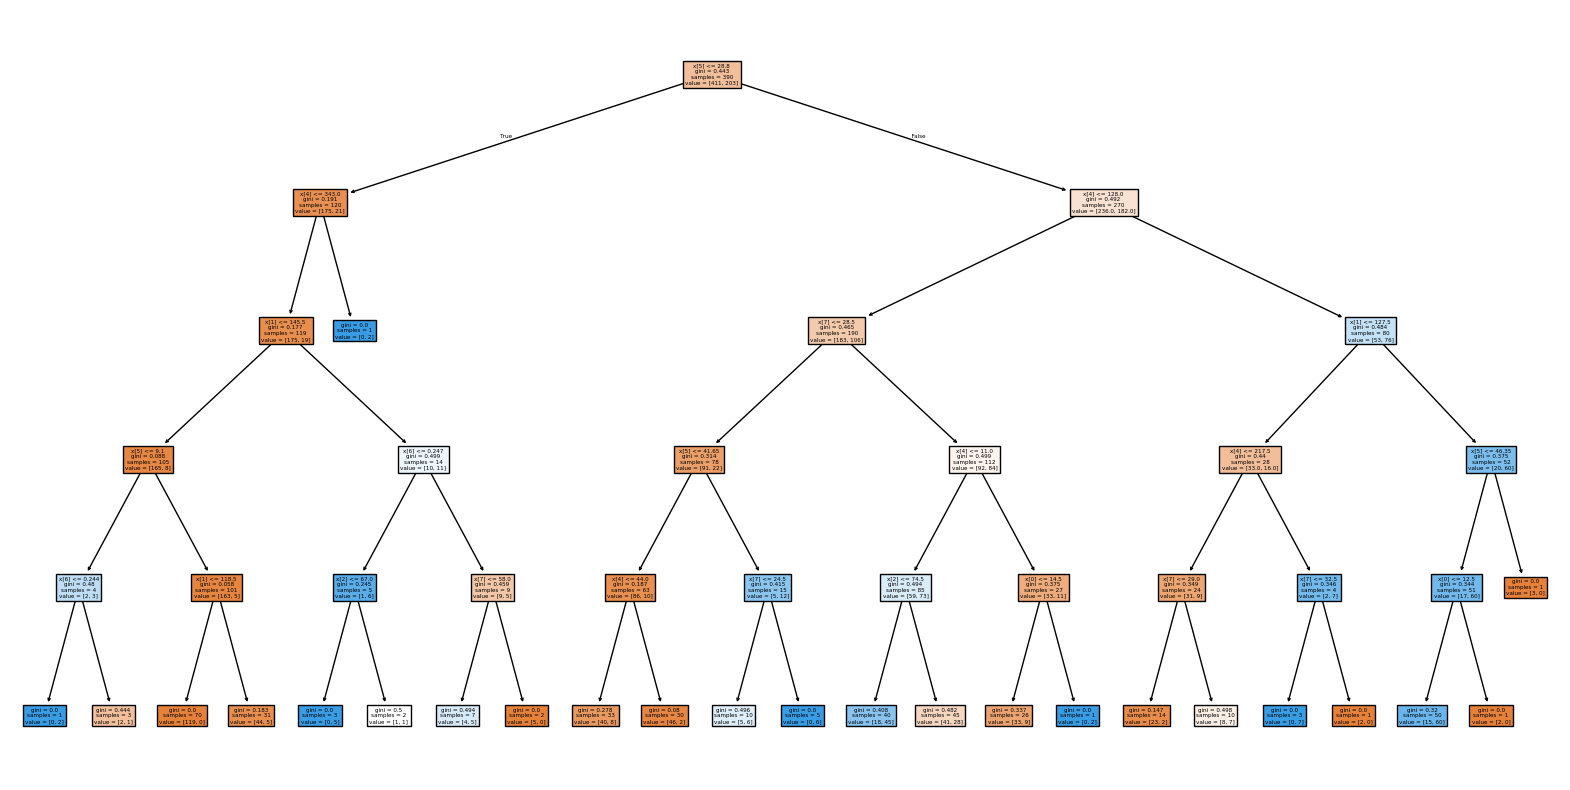

In [67]:
#Visualizamos el modelo
fig, axis = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
tree.plot_tree(model_opt.estimators_[0], filled=True, ax=axis)
plt.show()

**El modelo original procesó una profundidad de 15 niveles. En este caso limitamos a 5.**

In [68]:
#Predcción del modelo
y_opt_pred = model_opt.predict(X_test)
y_opt_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [69]:
accuracy_score(y_test, y_opt_pred)

0.7207792207792207

In [70]:
accuracy_score(y_test, y_opt_pred)
print(classification_report(y_test, y_opt_pred))

              precision    recall  f1-score   support

           0       0.75      0.85      0.80       100
           1       0.63      0.48      0.55        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.67       154
weighted avg       0.71      0.72      0.71       154



In [75]:
#Función que permite probar diferentes combinaciones de hiperparámetros
def test_hyperparameters(n_estimators, max_depth):
    model_opt = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model_opt.fit(X_train, y_train.values.ravel())
    y_opt_pred = model_opt.predict(X_test)
    print(f"n_estimators: {n_estimators}, max_depth: {max_depth}")
    print(classification_report(y_test, y_opt_pred))

**Generé comparación de resultados a partir de 4 combinaciones diferentes de hiperparámetros para ver su respuesta:**

| Métrica | Clase | Default | depth=5, est=200 | depth=20, est=100 | depth=15, est=500 |
|--------|-------|---------|------------------|-------------------|-------------------|
| Precision | 0 | 0.79 | 0.75 | 0.79 | 0.79 |
| Precision | 1 | 0.68 | 0.63 | 0.68 | 0.63 |
| Recall | 0 | 0.85 | 0.85 | 0.85 | 0.81 |
| Recall | 1 | 0.59 | 0.48 | 0.59 | 0.59 |
| F1-score | 0 | 0.82 | 0.80 | 0.82 | 0.80 |
| F1-score | 1 | 0.63 | 0.55 | 0.63 | 0.61 |
| Accuracy | - | 0.76 | 0.72 | 0.76 | 0.73 |
| Macro avg (F1) | - | 0.73 | 0.67 | 0.73 | 0.70 |
| Weighted avg (F1) | - | 0.76 | 0.71 | 0.76 | 0.73 |

**Intepretación: **
1. La configuración por defecto parece ser la óptima. Aumentar la profundidad no aporta ninguna mejora.
2. Por el lado contrario, reducir la profundidad también reduce el recall, F1 y accuracy. El árbol demasiado simple no aprende lo suficiente.

## Paso 3: Guarda el modelo

Almacena el modelo en la carpeta correspondiente.

In [78]:
import joblib
joblib.dump(model_opt, "../models/diabetes/random_forest_model.pkl")

['../models/diabetes/random_forest_model.pkl']